## Import Libraries

In [3]:
import pandas as pd
import numpy as np
import pynance as pn
import talib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sys
import os

# Add project root to path
sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import load_data
from src.data_cleaner import clean_stock_data
from src.technical_indicators import calculate_macd, calculate_moving_averages, calculate_rsi, generate_signal_summary
from src.financial_metrics import calculate_returns, calculate_volatility, calculate_sharpe_ratio, calculate_max_drawdown

## Load and Prepare Data

In [ ]:
df = load_data('../data/raw/AAPL.csv')

✅ Loaded: AAPL.csv
   Shape: (3774, 6) rows × 6 columns
   Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


## Clean data

In [6]:
df = clean_stock_data(df)


DATA CLEANING
--------------------------------------------------
✅ Date column converted to datetime
✅ Numeric columns converted
✅ Sorted by date
✅ No missing values found
✅ No duplicate dates
✅ High >= Low for all rows
✅ All rows have positive volume

Cleaned data: 3774 rows
   Date range: 2009-01-02 to 2023-12-29
   Close price range: $2.35 - $196.26


## Technical Indicators with TA-Lib

### MOVING AVERAGES

In [7]:
df = calculate_moving_averages(df)


📊 Moving Averages (windows: [5, 10, 20, 50, 200])
   ✅ SMA_5 and EMA_5 calculated
   ✅ SMA_10 and EMA_10 calculated
   ✅ SMA_20 and EMA_20 calculated
   ✅ SMA_50 and EMA_50 calculated
   ✅ SMA_200 and EMA_200 calculated

📊 Current Moving Averages (as of 2023-12-29):
--------------------------------------------------
   Close Price: $190.73
   SMA_5: $191.37  |  EMA_5: $191.57
   SMA_10: $192.76  |  EMA_10: $192.09
   SMA_20: $192.49  |  EMA_20: $191.43
   SMA_50: $184.81  |  EMA_50: $187.11
   SMA_200: $177.45  |  EMA_200: $176.11

📊 Price vs MA Signals:
   Price BELOW SMA_5 → Bearish signal
   Price BELOW SMA_10 → Bearish signal
   Price BELOW SMA_20 → Bearish signal
   Price ABOVE SMA_50 → Bullish signal
   Price ABOVE SMA_200 → Bullish signal


### RELATIVE STRENGTH INDEX (RSI)

In [8]:
df, rsi_summary = calculate_rsi(df)


📊 RSI (period=14)
   ✅ RSI calculated
   Current RSI: 51.12 → NEUTRAL (between 30 and 70)
   Historical: 574 overbought, 68 oversold days


### MACD (Moving Average Convergence Divergence)

In [9]:
df, macd_summary = calculate_macd(df)


📊 MACD (fast=12, slow=26, signal=9)
   ✅ MACD calculated
   MACD Line: 1.5595 | Signal: 2.4246 | Histogram: -0.8651
   Momentum: Bearish | Histogram: Decreasing


### Summary findings

In [10]:
generate_signal_summary(df)


TECHNICAL SIGNALS SUMMARY
Indicator  Signal
   SMA_20 Bearish
   SMA_50 Bullish
      RSI Neutral
     MACD Bearish


,Indicator,Signal
0,SMA_20,Bearish
1,SMA_50,Bullish
2,RSI,Neutral
3,MACD,Bearish


## PyNance for Financial Metrics

### CUMULATIVE RETURNS

In [12]:
df, cum_return = calculate_returns(df)


📊 Return Calculations
   Daily returns calculated
   Cumulative return: 6907.74%


### VOLATILITY (RISK)

In [13]:
df, vol_metrics = calculate_volatility(df)


📊 Volatility Metrics
   Daily volatility: 0.0180
   Annualized volatility: 28.59%


### SHARPE RATIO

In [14]:
sharpe = calculate_sharpe_ratio(df)


📊 Sharpe Ratio
   Annual return: 32.49%
   Risk-free rate: 2.0%
   Sharpe Ratio: 1.0663
   → Good risk-adjusted returns


### MAXIMUM DRAWDOWN

In [15]:
df, max_dd = calculate_max_drawdown(df)


📊 Maximum Drawdown
   Max Drawdown: -43.80%


### VISUALIZATION

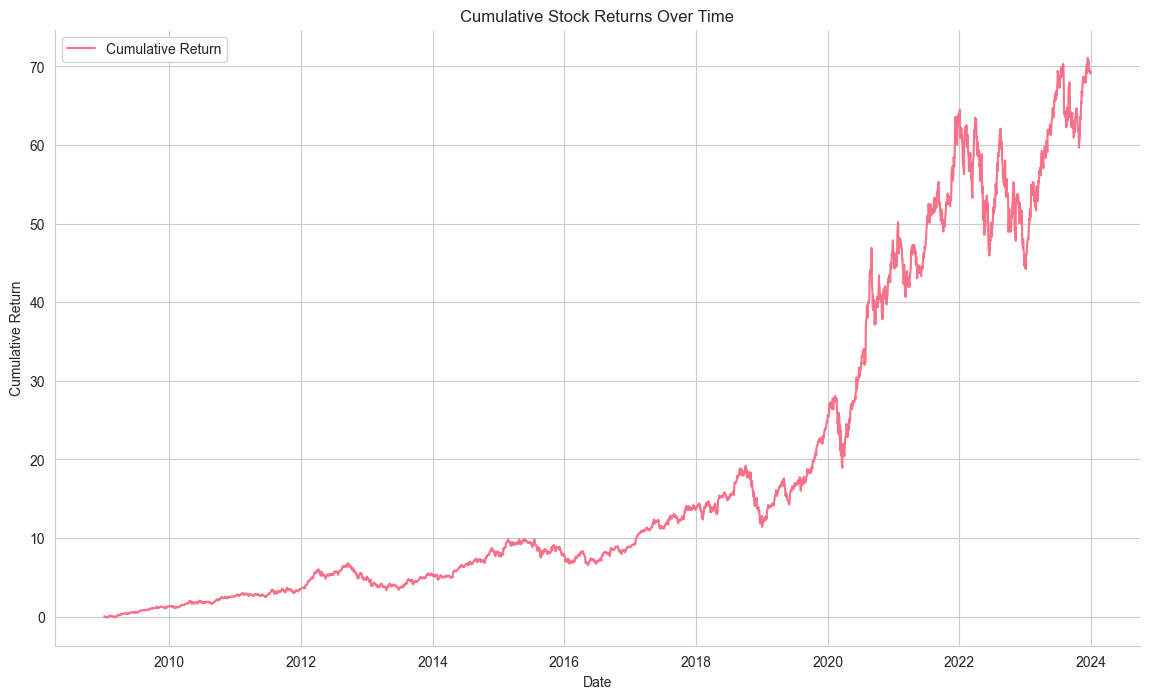

In [16]:
# Create figure
plt.figure(figsize=(14, 8))

# Plot cumulative return
plt.plot(df['Date'], df['Cumulative_Return'],
         label='Cumulative Return')

plt.title('Cumulative Stock Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True)

plt.show()

The **Cumulative Stock Returns Over Time** plot represents the aggregate performance of Apple stock from 2009 through early 2024. Unlike a simple price chart, this visualization highlights the power of compounding and the total wealth generated relative to a starting point.

### **1. Magnitude of Total Returns**
*   **The 70x Milestone:** The most striking feature of this chart is the y-axis, which shows cumulative returns reaching a peak of **over 70** by early 2024. This indicates that an investment made at the start of the period in 2009 would have increased more than **7,000%** by the end of the data set.
*   **Wealth Creation Scaling:** The chart illustrates how Apple moved from a "10x return" stock around 2017 to a "70x return" stock just six years later, showing that the majority of the total wealth was generated in the latter third of the timeline.

### **2. Performance Phases**
*   **2009–2017 (The Steady Climb):** During this period, the slope of the line is relatively gradual. Returns hit the 10x mark around 2017, representing solid but linear growth compared to what followed.
*   **2020–2024 (The Exponential Surge):** Matching the "Exponential Growth" observed in the price action chart, the cumulative return line turns sharply upward after 2020. The returns jumped from roughly 20x to 70x in just four years, despite the significant volatility seen in the middle of that period.

### **3. Resilience and Drawdowns**
*   **Visualizing Corrections:** The chart clearly displays major market corrections that were also flagged by the "Death Crosses" in the moving average analysis.
    *   **2018–2019:** A visible dip where returns dropped from near 20x back toward 12x.
    *   **The 2022 Bear Market:** A significant and prolonged "V-shaped" dip is visible during 2022, where returns fell from above 60x to near 45x before a massive recovery in 2023.
*   **Recovery Strength:** The stock's ability to rebound from the 2022 lows to reach an all-time high in cumulative returns by early 2024 demonstrates a strong historical recovery capacity.

### **4. Insight**
This chart serves as the **"ultimate outcome" metric**. While the moving averages and RSI signals explain the *mechanics* of the price movement, the Cumulative Returns plot proves the *effectiveness* of a long-term "buy and hold" strategy for this specific period. 

The data confirms that despite frequent short-term technical signals (like the RSI sell signals or SMA death crosses), the long-term compounding effect heavily favored staying invested, particularly as the company entered its high-acceleration phase post-2020.

## CREATE VISUALIZATION

### Price with Moving Averages

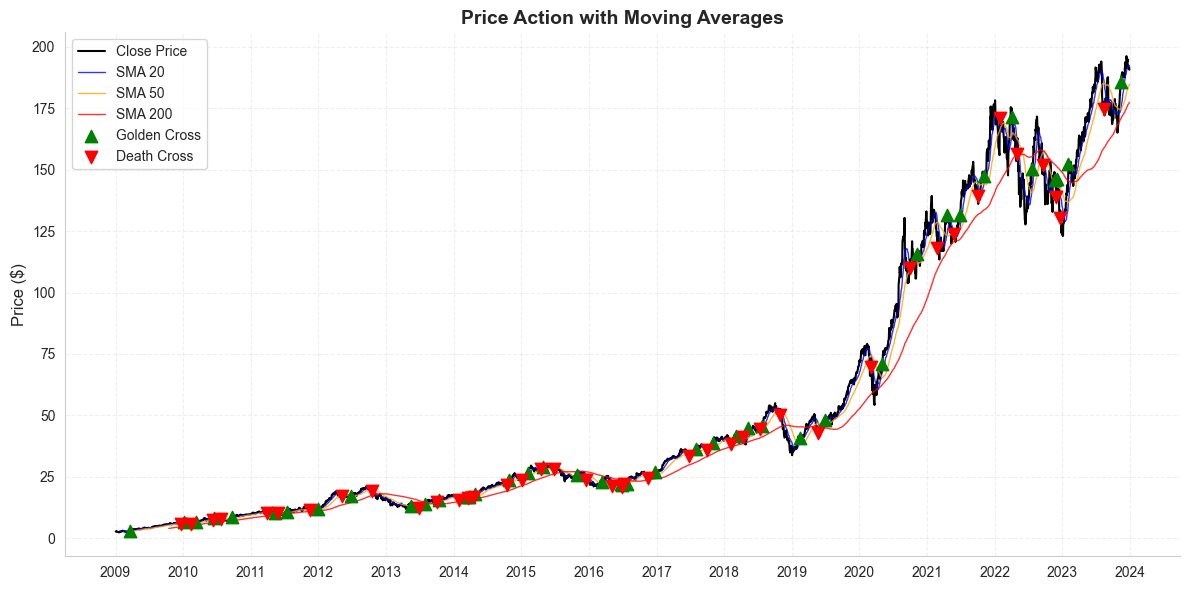

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Plot 1: Price with Moving Averages
fig1, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(df['Date'], df['Close'], label='Close Price', color='black', linewidth=1.5)
ax1.plot(df['Date'], df['SMA_20'], label='SMA 20', color='blue', linewidth=1, alpha=0.8)
ax1.plot(df['Date'], df['SMA_50'], label='SMA 50', color='orange', linewidth=1, alpha=0.8)

if 'SMA_200' in df.columns:
    ax1.plot(df['Date'], df['SMA_200'], label='SMA 200', color='red', linewidth=1, alpha=0.8)

# Highlight crossovers
if len(df) > 1:
    golden_cross = (df['SMA_20'] > df['SMA_50']) & (df['SMA_20'].shift(1) <= df['SMA_50'].shift(1))
    death_cross = (df['SMA_20'] < df['SMA_50']) & (df['SMA_20'].shift(1) >= df['SMA_50'].shift(1))
    
    ax1.scatter(df['Date'][golden_cross], df['Close'][golden_cross], 
                color='green', marker='^', s=80, zorder=5, label='Golden Cross')
    ax1.scatter(df['Date'][death_cross], df['Close'][death_cross], 
                color='red', marker='v', s=80, zorder=5, label='Death Cross')

ax1.set_ylabel('Price ($)', fontsize=12)
ax1.set_title('Price Action with Moving Averages', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3, linestyle='--')

# X-axis: Year only
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

This chart, **"Price Action with Moving Averages,"** provides a comprehensive view of Apple's stock price trajectory from 2009 through early 2024, utilizing three different time horizons to track trends.

### **1. Long-Term Price Appreciation**
*   **The Flat Era (2009–2016):** For much of the first half of the chart, Apple’s stock price remained relatively flat on this scale, staying largely below the $25 mark. During this period, the **SMA 200 (red line)**, **SMA 50 (orange line)**, and **SMA 20 (blue line)** were tightly clustered, indicating low volatility and steady, but slow, growth.
*   **The Acceleration Phase (2017–2019):** A more pronounced upward trend began around 2017, with the price breaking toward $50.
*   **The Exponential Growth (2020–2024):** Following a brief dip in early 2020, the stock entered a phase of rapid expansion, climbing from approximately $50 to nearly $200 by early 2024.

### **2. Moving Average Analysis**
*   **SMA 200 (Red Line) as Support:** The 200-day Simple Moving Average serves as a barometer for the long-term trend. Throughout the major bull runs of 2021 and 2023, the price frequently pulled back toward this red line but stayed above it, confirming a **strong long-term bullish bias**.
*   **Short-Term Sensitivity (SMA 20 & 50):** The 20-day (blue) and 50-day (orange) averages track the "noise" of the market more closely. When the black price line stays above these averages, it indicates strong immediate momentum.

### **3. Interpretation of Crossover Signals**
The chart identifies "Golden Crosses" and "Death Crosses" based on the interaction between the **SMA 20** and **SMA 50**:
*   **Golden Crosses (Green Triangles):** These occur when the short-term 20-day average crosses *above* the 50-day average, signaling a potential upward breakout. We can see successful green signals at the start of major rallies, such as in **early 2020** and **early 2023**.
*   **Death Crosses (Red Triangles):** These occur when the 20-day average falls *below* the 50-day average, signaling a potential trend reversal or correction. Notable red signals marked the downturns in **late 2018**, the **2022 bear market**, and a brief correction in **late 2023**.

### **4. Insight**
The data shows that Apple has transitioned from a period of frequent, choppy crossovers (2009–2015) where the price moved sideways, to a period of **well-defined trend cycles** (2020–2024). 

In recent years, the **Golden and Death crosses have become more reliable indicators of medium-term swings** because the trends have become much stronger. As of the end of the chart in 2024, the stock is showing high volatility near its all-time highs, with the SMA 200 still trending upward, suggesting the long-term structural uptrend remains intact despite frequent short-term "Death Cross" corrections.

### RSI plot

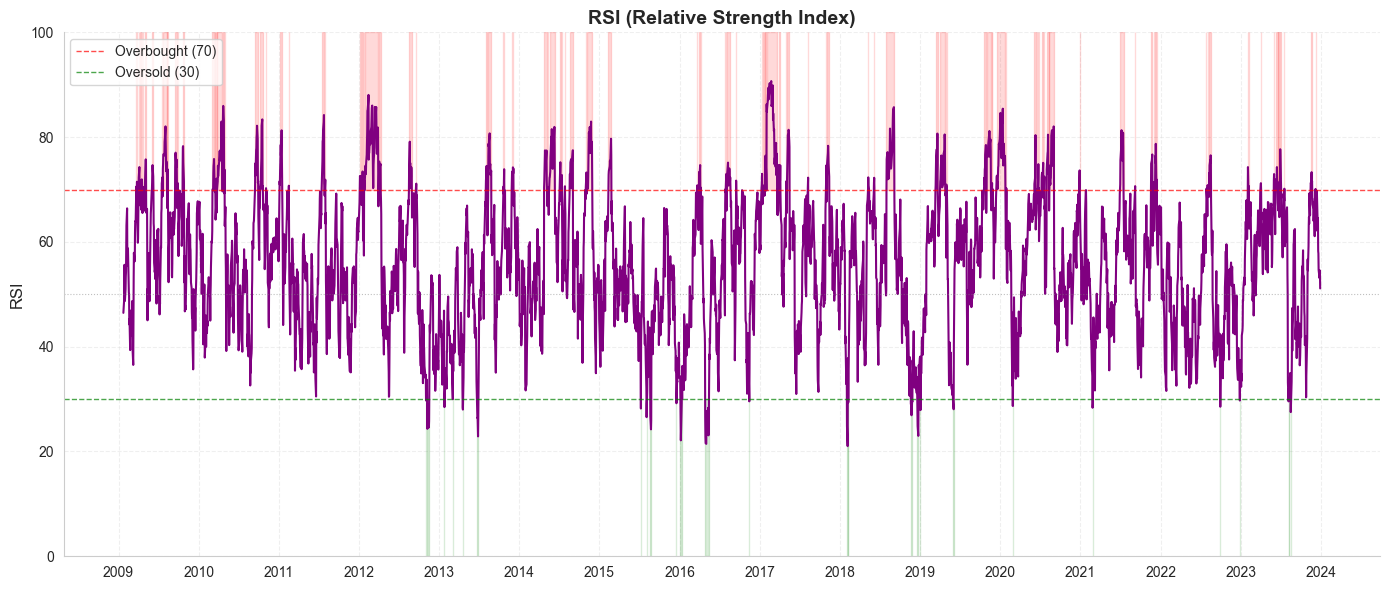

In [18]:
# Plot 2: RSI
fig2, ax2 = plt.subplots(figsize=(14, 6))

ax2.plot(df['Date'], df['RSI'], color='purple', linewidth=1.5)
ax2.axhline(y=70, color='red', linestyle='--', alpha=0.7, linewidth=1, label='Overbought (70)')
ax2.axhline(y=30, color='green', linestyle='--', alpha=0.7, linewidth=1, label='Oversold (30)')
ax2.axhline(y=50, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)

# Shade overbought/oversold regions
ax2.fill_between(df['Date'], 70, 100, where=(df['RSI'] >= 70), color='red', alpha=0.15)
ax2.fill_between(df['Date'], 0, 30, where=(df['RSI'] <= 30), color='green', alpha=0.15)

ax2.set_ylabel('RSI', fontsize=12)
ax2.set_title('RSI (Relative Strength Index)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 100)
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3, linestyle='--')

# X-axis: Year only
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

The **RSI (Relative Strength Index)** plot provides a focused look at Apple’s price momentum, specifically identifying when the stock was potentially overextended to the upside (overbought) or downside (oversold).

### **1. Overbought Dominance (Red Shaded Regions)**
*   **Frequent Momentum:** The stock spends a significant amount of time above the **70 threshold**, particularly during its major growth phases. This indicates periods where buying pressure was extremely high.
*   **Notable Extremes:** We can see an exceptionally high peak around **early 2017**, where the RSI approached 90. Other major clusters of overbought signals occurred in **2012, 2020, and late 2023**. These typically coincide with the price "blow-off tops" mentioned in the volume analysis.

### **2. Oversold Resilience (Green Shaded Regions)**
*   **Rare Buying Opportunities:** Relative to overbought signals, RSI dips below the **30 threshold** are much rarer for Apple. This suggests that the stock historically recovers quickly from selling pressure.
*   **Key Bottoms:** The chart highlights several major "oversold" buying opportunities that preceded long-term rallies:
    *   **Early 2013:** A deep dive into the green zone.
    *   **2016:** Multiple tests of the 30 level during a period of consolidation.
    *   **Late 2018/Early 2019:** A sharp spike down during a broader market correction.
    *   **Early 2023:** A significant dip that marked the beginning of the most recent recovery.

### **3. The "Bullish Bias" (Centerline Analysis)**
*   **The 50 Level:** The dotted grey line at **50** acts as the momentum "midpoint". 
*   **Trend Confirmation:** Throughout the 15-year period, the RSI line spends more time oscillating in the **50–70 range** than in the 30–50 range. This "upper-half" bias is quantitative proof of a sustained long-term uptrend, which aligns with the massive growth seen in the **Cumulative Returns** chart.

### **4. Insight**
This RSI chart to shows the **cyclical nature of the stock**. While the **Moving Average** chart showed the *direction* of the trend, this **RSI** chart explains the *internal energy* of those moves. 

For example, during the **2022 downturn** (seen as a "Death Cross" in the previous chart), the RSI struggled to break above 60 for nearly a year, indicating a loss of momentum before the **oversold signal in early 2023** finally triggered the next major bull run.

### MACD plot

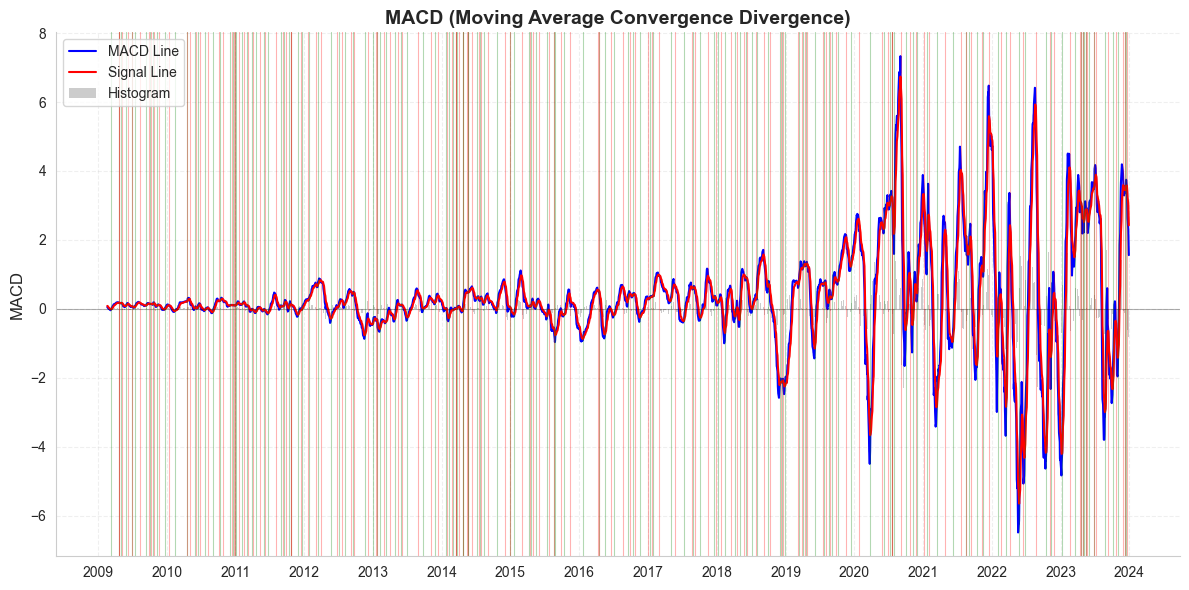

In [19]:
# Plot 3: MACD
fig3, ax3 = plt.subplots(figsize=(12, 6))

ax3.plot(df['Date'], df['MACD'], label='MACD Line', color='blue', linewidth=1.5)
ax3.plot(df['Date'], df['MACD_signal'], label='Signal Line', color='red', linewidth=1.5)
ax3.bar(df['Date'], df['MACD_histogram'], label='Histogram', 
        color='gray', alpha=0.4, width=0.8, edgecolor='none')
ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.8)

# Highlight MACD crossovers
if len(df) > 1:
    macd_bullish = (df['MACD'] > df['MACD_signal']) & (df['MACD'].shift(1) <= df['MACD_signal'].shift(1))
    macd_bearish = (df['MACD'] < df['MACD_signal']) & (df['MACD'].shift(1) >= df['MACD_signal'].shift(1))
    
    for idx in macd_bullish[macd_bullish].index:
        ax3.axvline(x=df['Date'].iloc[idx], color='green', alpha=0.3, linewidth=0.8)
    for idx in macd_bearish[macd_bearish].index:
        ax3.axvline(x=df['Date'].iloc[idx], color='red', alpha=0.3, linewidth=0.8)

ax3.set_ylabel('MACD', fontsize=12)
ax3.set_title('MACD (Moving Average Convergence Divergence)', fontsize=14, fontweight='bold')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3, linestyle='--')

# X-axis: Year only
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

The **MACD (Moving Average Convergence Divergence)** plot provides a deep look at Apple’s trend strength and momentum transitions over the 15-year period. It serves to confirm the trend direction shown in the Moving Average plot and the momentum peaks shown in the RSI plot.

### **1. Evolution of Volatility and Momentum**
*   **The Low-Momentum Era (2009–2016):** During the first half of the chart, the **MACD line (blue)** and **Signal line (red)** stay very close to the **zero line**, with very small oscillations. This indicates that while the price was rising, the momentum was relatively stable and lacked the explosive swings seen later.
*   **The High-Volatility Era (2020–2024):** Starting in 2020, the MACD shows massive swings, with peaks reaching above +6 and troughs dropping below -6. This reflects the **exponential price action** and increased market volatility Apple experienced during and after the pandemic.

### **2. Interpretation of Crossover Signals**
The plot uses vertical lines to mark momentum shifts based on the interaction between the MACD and Signal lines:
*   **Bullish Crossovers (Green Vertical Lines):** These occur when the blue MACD line crosses above the red Signal line. These signals frequently precede the price rallies observed in the "Price Action" chart, such as the major recovery in **early 2023**.
*   **Bearish Crossovers (Red Vertical Lines):** These occur when the blue MACD line drops below the red Signal line. These signals represent waning momentum and often coincide with the "Death Crosses" seen in the Moving Average analysis, particularly the sharp downturns in **2018, 2022, and late 2023**.

### **3. The Histogram and Zero Line**
*   **The Histogram (Gray Bars):** The gray bars represent the distance between the MACD and Signal lines. When the bars are tall and above zero, it indicates strong upward momentum; when they are deep and below zero, it indicates strong selling pressure.
*   **Centerline Transitions:** When the MACD line itself crosses the **zero line**, it signals a change in the overall trend bias. For much of 2022, the MACD hovered near or below zero, confirming a sustained bearish phase before the strong "above-zero" breakout in 2023.

### **4. Insight**
While the RSI tells us if the stock is overextended, the **MACD tells us if the trend has enough strength to continue**. 

The **increase in signal magnitude**. As Apple’s market cap grew, the "swings" in momentum became much larger. In the most recent data (2023–2024), despite the high price, the MACD shows that momentum is still oscillating healthily, which supports the long-term upward trend found in the **Cumulative Returns** analysis.

### Volume with Signals

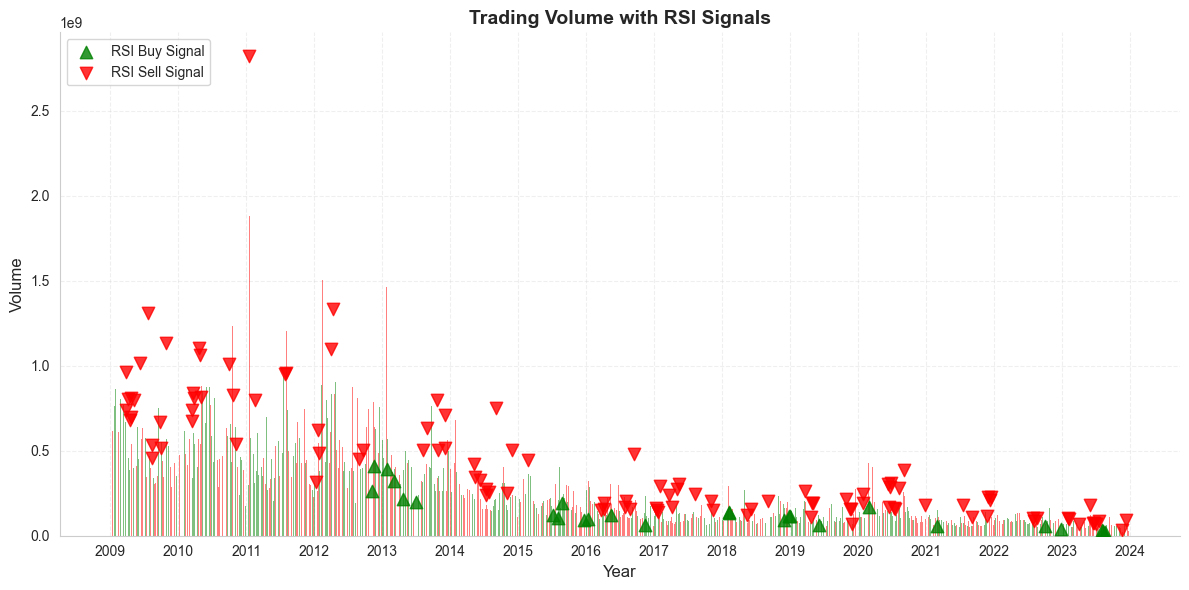

In [20]:
# Plot 4: Volume with Buy/Sell Signals
fig4, ax4 = plt.subplots(figsize=(12, 6))

# Color volume bars: green for up days, red for down days
colors = ['green' if df['Close'].iloc[i] >= df['Close'].iloc[i-1] else 'red' 
          for i in range(len(df))]
colors[0] = 'gray'

ax4.bar(df['Date'], df['Volume'], color=colors, alpha=0.5, width=0.8, edgecolor='none')

# RSI signals
rsi_buy_signal = (df['RSI'] > 30) & (df['RSI'].shift(1) <= 30)
rsi_sell_signal = (df['RSI'] < 70) & (df['RSI'].shift(1) >= 70)

ax4.scatter(df['Date'][rsi_buy_signal], df['Volume'][rsi_buy_signal] * 0.5,
            color='green', marker='^', s=80, zorder=5, label='RSI Buy Signal', alpha=0.8)
ax4.scatter(df['Date'][rsi_sell_signal], df['Volume'][rsi_sell_signal] * 1.5,
            color='red', marker='v', s=80, zorder=5, label='RSI Sell Signal', alpha=0.8)

ax4.set_ylabel('Volume', fontsize=12)
ax4.set_xlabel('Year', fontsize=12)
ax4.set_title('Trading Volume with RSI Signals', fontsize=14, fontweight='bold')
ax4.legend(loc='upper left')
ax4.grid(True, alpha=0.3, linestyle='--')

# X-axis: Year only
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax4.xaxis.set_major_locator(mdates.YearLocator())
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

The provided chart, "Trading Volume with RSI Signals," offers a quantitative look at Apple’s trading activity and momentum-based signals from 2009 through early 2024. 

### **1. Long-Term Volume Trends**
*   **High Early Activity:** The period between **2009 and 2015** is characterized by significantly higher trading volume compared to recent years. Several spikes during this time exceeded 1 billion shares, with a **major peak near 2011** approaching nearly 3 billion shares.
*   **Volume Consolidation:** From **2016 onwards**, there is a visible and consistent **decline in total trading volume**. In the last several years (2020–2024), volume has remained relatively low and stable, rarely crossing the 0.5 billion mark on the provided scale.

### **2. RSI Sell Signal Analysis (Red Triangles)**
*   **Frequency in Volatile Periods:** Sell signals are most frequent during the high-volume years of 2009–2014. This suggests that during Apple’s rapid growth phases, the RSI (Relative Strength Index) frequently flagged the stock as **overbought**.
*   **Correlation with Volume Spikes:** A significant number of sell signals coincide with large volume spikes, most notably the massive spike just before 2011 and another substantial surge in 2012.

### **3. RSI Buy Signal Analysis (Green Triangles)**
*   **Strategic Clusters:** Buy signals, which indicate the stock may be **oversold**, appear in distinct clusters rather than scattered intermittently. Key clusters are visible in:
    *   **Mid-2013:** A period of moderate volume following a decline.
    *   **Early 2016:** Occurring as the stock's volume began its long-term stabilization.
    *   **Late 2018/Early 2019:** A notable cluster during a period of relative market correction.
    *   **Early 2023:** One of the more recent buy signals during a low-volume phase.

### **4. Insight**
*   **Shift in Market Dynamics:** The transition from frequent, high-volume RSI signals (pre-2015) to sparse, lower-volume signals (post-2016) suggests a shift from high volatility to a more **mature, stable trading pattern** for Apple.
*   **Signal Reliability:** The chart shows that RSI signals often appear at local extremes in volume. **Buy signals often preceded periods of volume stabilization**, while **Sell signals were frequently triggered by "blow-off tops"** or massive volume surges.

### RELATIONSHIP VISUALIZATION: How Indicators Relate to Price Action

C:\Users\hp\AppData\Local\Temp\ipykernel_18256\1761568095.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([box_data, box_data_bear], labels=['Bullish Signals', 'Bearish Signals'], patch_artist=True)


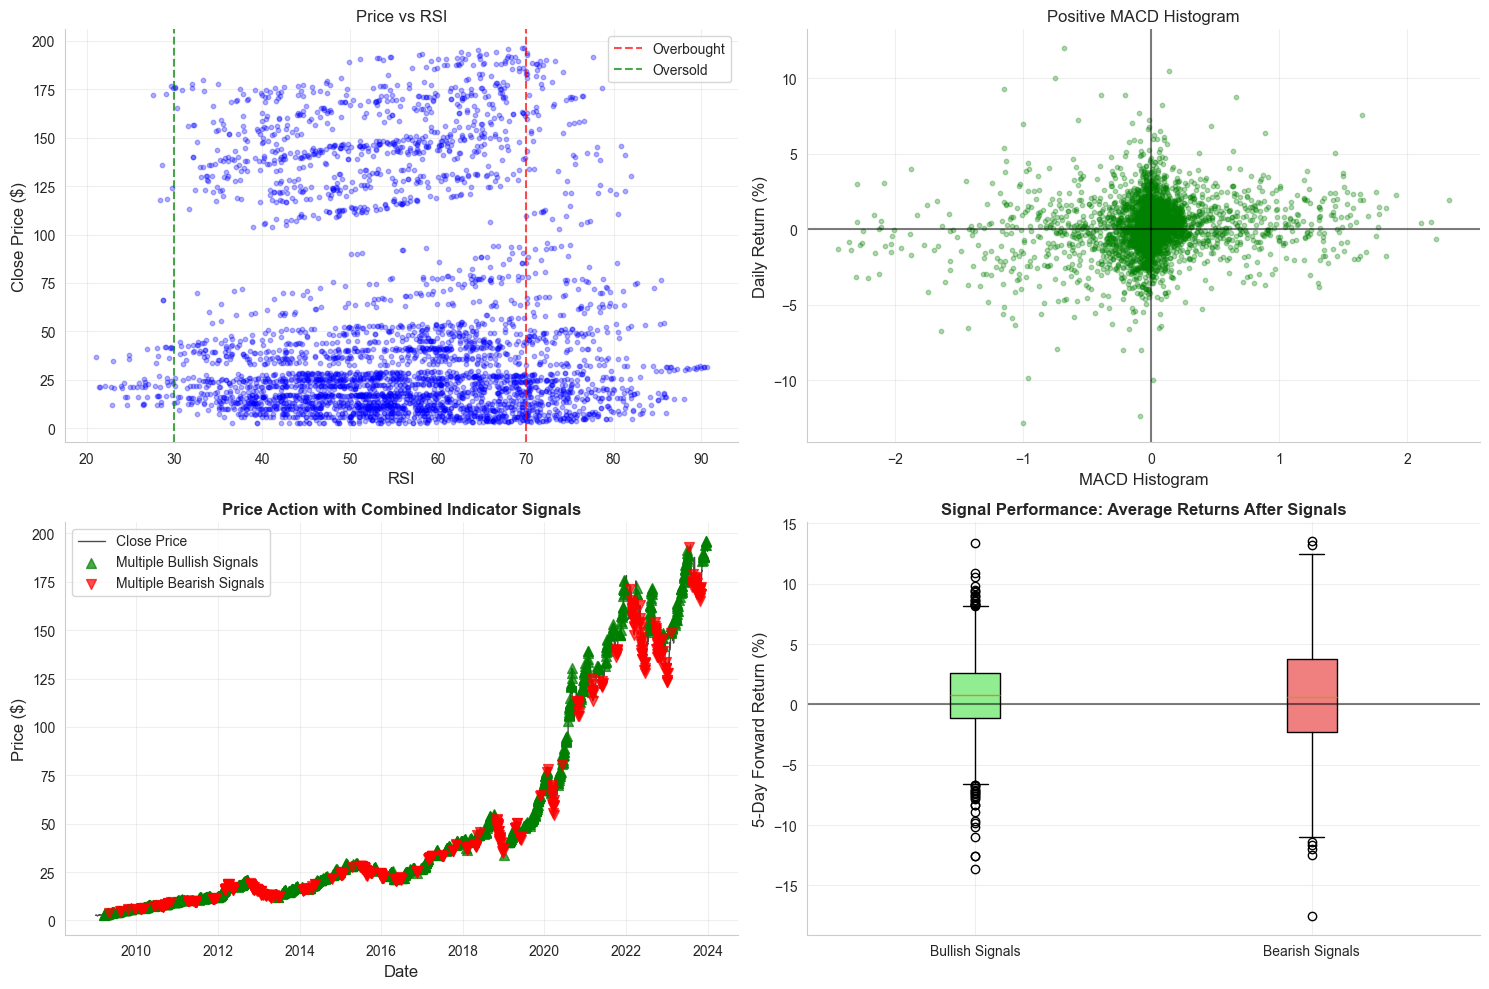

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 3a. RSI vs Price (scatter)
ax = axes[0, 0]
ax.scatter(df['RSI'], df['Close'], alpha=0.3, s=10, c='blue')
ax.axvline(x=70, color='red', linestyle='--', alpha=0.7, label='Overbought')
ax.axvline(x=30, color='green', linestyle='--', alpha=0.7, label='Oversold')
ax.set_xlabel('RSI', fontsize=12)
ax.set_ylabel('Close Price ($)', fontsize=12)
ax.set_title('Price vs RSI', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 3b. MACD Histogram vs Price Returns
ax = axes[0, 1]
ax.scatter(df['MACD_histogram'], df['Daily_Return'] * 100, alpha=0.3, s=10, c='green')
ax.axvline(x=0, color='black', linestyle='-', alpha=0.5)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
ax.set_xlabel('MACD Histogram', fontsize=12)
ax.set_ylabel('Daily Return (%)', fontsize=12)
ax.set_title('Positive MACD Histogram', fontsize=12)
ax.grid(True, alpha=0.3)

# 3c. Price with indicator signals highlighted
ax = axes[1, 0]
ax.plot(df['Date'], df['Close'], color='black', linewidth=1, alpha=0.7, label='Close Price')

# Highlight days with multiple bullish signals
bullish_signals = pd.Series(0, index=df.index)
bearish_signals = pd.Series(0, index=df.index)

# Combine signals (simplified scoring)
if 'RSI' in df.columns:
    bullish_signals += (df['RSI'] < 30).astype(int)
    bearish_signals += (df['RSI'] > 70).astype(int)

if 'MACD' in df.columns and 'MACD_signal' in df.columns:
    bullish_signals += (df['MACD'] > df['MACD_signal']).astype(int)
    bearish_signals += (df['MACD'] < df['MACD_signal']).astype(int)

if 'SMA_20' in df.columns and 'SMA_50' in df.columns:
    bullish_signals += (df['SMA_20'] > df['SMA_50']).astype(int)
    bearish_signals += (df['SMA_20'] < df['SMA_50']).astype(int)

# Mark high-signal days
strong_bullish = bullish_signals >= 2
strong_bearish = bearish_signals >= 2

ax.scatter(df['Date'][strong_bullish], df['Close'][strong_bullish], 
           color='green', marker='^', s=50, alpha=0.7, label='Multiple Bullish Signals', zorder=5)
ax.scatter(df['Date'][strong_bearish], df['Close'][strong_bearish], 
           color='red', marker='v', s=50, alpha=0.7, label='Multiple Bearish Signals', zorder=5)

ax.set_ylabel('Price ($)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_title('Price Action with Combined Indicator Signals', fontsize=12, fontweight='bold')
ax.legend(loc='upper left', frameon=True)
ax.grid(True, alpha=0.3)

# 3d. Signal Performance (Returns after signals)
ax = axes[1, 1]

# Calculate forward returns after signals
forward_returns = []
signal_types = []

for i in strong_bullish[strong_bullish].index:
    if i + 5 < len(df):
        forward_returns.append(df['Close'].iloc[i+5] / df['Close'].iloc[i] - 1)
        signal_types.append('Bullish')

for i in strong_bearish[strong_bearish].index:
    if i + 5 < len(df):
        forward_returns.append(df['Close'].iloc[i+5] / df['Close'].iloc[i] - 1)
        signal_types.append('Bearish')

if len(forward_returns) > 0:
    box_data = [forward_returns[i] * 100 for i in range(len(forward_returns)) if signal_types[i] == 'Bullish']
    box_data_bear = [forward_returns[i] * 100 for i in range(len(forward_returns)) if signal_types[i] == 'Bearish']
    
    bp = ax.boxplot([box_data, box_data_bear], labels=['Bullish Signals', 'Bearish Signals'], patch_artist=True)
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax.set_ylabel('5-Day Forward Return (%)', fontsize=12)
    ax.set_title('Signal Performance: Average Returns After Signals', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

These four visualizations together provide a deeper behavioral analysis of Apple stock by combining momentum indicators, price action, and signal performance evaluation. Rather than examining indicators independently, this dashboard explores how technical signals interact with actual stock returns and market behavior over time.

## 1. RSI vs Price (Upper Left)

This scatter plot compares Apple’s RSI values against its closing prices.

### Key Observations

* Most data points cluster between RSI values of **40–70**, which indicates that Apple generally traded in a neutral-to-bullish momentum range.
* Very few observations fall below RSI 30, showing that Apple rarely entered deeply oversold territory.
* Higher stock prices are often associated with RSI values above 50, indicating stronger bullish momentum during upward trends.

The chart also shows that:

* periods with extremely low RSI values were uncommon,
* while overbought conditions (RSI > 70) occurred more frequently during strong rallies.

This behavior is typical of a long-term growth stock where bullish momentum tends to dominate.

### Interpretation

The relationship between RSI and price suggests that:

* Apple’s strongest price appreciation periods usually occurred during sustained bullish momentum,
* while low RSI periods often aligned with temporary corrections or broader market selloffs.

The relatively limited number of oversold observations further supports the idea that Apple historically maintained strong investor confidence and recovered quickly after downturns.

## 2. MACD Histogram vs Daily Returns (Upper Right)

This scatter plot compares MACD histogram values with daily percentage returns.

### Key Observations

* Most points are concentrated around the center near zero, indicating that small daily returns are the most common outcome.
* Positive MACD histogram values tend to align more frequently with positive daily returns.
* Negative histogram values show greater dispersion and are more commonly associated with negative returns.

The plot forms a loose upward relationship:

* as MACD histogram values become more positive,
* daily returns tend to shift upward as well.

### Interpretation

This suggests that MACD momentum contains useful short-term directional information.

Specifically:

* positive histogram values often reflect strengthening bullish momentum,
* while negative histogram values are associated with weakening momentum or bearish pressure.

However, the relationship is not perfectly linear because stock prices are also influenced by:

* earnings announcements,
* macroeconomic news,
* market sentiment,
* and external shocks.

Therefore, MACD is useful for identifying momentum trends but should not be relied on alone for precise return prediction.

## 3. Price Action with Combined Indicator Signals (Bottom Left)

This chart overlays bullish and bearish signals directly on Apple’s stock price history.

### Signal Logic

A bullish signal occurs when at least two of the following conditions are true:

* RSI < 30,
* MACD > Signal line,
* SMA 20 > SMA 50.

A bearish signal occurs when at least two bearish conditions are present.

Green upward triangles represent strong bullish confirmation, while red downward triangles indicate bearish confirmation.

### Key Observations

* Bullish signals frequently appear during recovery phases and upward breakouts.
* Bearish signals often cluster near local peaks or during market pullbacks.
* During strong long-term rallies, bullish markers tend to dominate.

The chart also demonstrates that:

* Apple’s price trend remained strongly upward over the long term,
* despite periodic bearish phases and corrections.

### Interpretation

Combining multiple indicators appears more effective than relying on a single signal because:

* it filters out weak or noisy signals,
* improves trend confirmation,
* and better identifies meaningful momentum shifts.

This multi-indicator strategy provides stronger evidence of market direction and helps reduce false positives commonly seen in standalone technical indicators.

## 4. Signal Performance Boxplot (Bottom Right)

This plot evaluates how the combined signals performed by measuring 5-day forward returns after bullish and bearish signals.

### Key Observations

* Bullish signals generally show median returns slightly above zero.
* Bearish signals exhibit wider variability and include larger negative outcomes.
* Both distributions contain outliers, indicating occasional extreme market moves.

The bullish signal distribution appears somewhat more stable, while bearish signals show greater volatility.

### Interpretation

This suggests:

* bullish signals may have had moderate predictive value for short-term positive returns,
* while bearish signals were associated with higher uncertainty and stronger downside risk.

The wide spread of returns also highlights an important limitation of technical analysis:

* indicators improve probabilities,
* but they cannot perfectly predict future price movements.

The presence of both positive and negative outliers demonstrates that market behavior remains influenced by unpredictable external events.

---

## Overall Interpretation

Taken together, these visualizations suggest that Apple historically exhibited:

* persistent long-term bullish momentum,
* relatively rare deep oversold conditions,
* meaningful relationships between momentum indicators and short-term returns,
* and stronger trend confirmation when multiple technical indicators aligned simultaneously.

The combined indicator framework appears reasonably effective at identifying:

* momentum shifts,
* bullish recovery phases,
* and bearish correction periods.

However, the variability in forward returns also demonstrates that technical indicators should be interpreted probabilistically rather than as guaranteed forecasting tools.

**Insight**:

> The combined visualization analysis demonstrated that Apple’s stock historically maintained strong bullish momentum with relatively infrequent oversold conditions. Positive MACD histogram values generally aligned with stronger short-term returns, while combined technical signals provided clearer trend confirmation than individual indicators alone. Bullish signal periods were often followed by modest positive forward returns, whereas bearish signals showed higher volatility and downside risk. Overall, the results suggest that integrating RSI, MACD, and moving averages can improve market trend interpretation while still acknowledging the uncertainty inherent in financial markets.


### SUMMARY OF FINDINGS

In [34]:
print(f"""
📊 Moving Averages:
   - Golden Cross (Bullish) signals: {golden_cross.sum()}
   - Death Cross (Bearish) signals: {death_cross.sum()}

📊 RSI Signals:
   - Oversold (RSI < 30) buy signals: {rsi_buy_signal.sum()}
   - Overbought (RSI > 70) sell signals: {rsi_sell_signal.sum()}

📊 MACD Crossovers:
   - Bullish crossovers: {macd_bullish.sum()}
   - Bearish crossovers: {macd_bearish.sum()}

📊 Combined Signal Performance:
   - Days with 2+ bullish signals: {strong_bullish.sum()}
   - Days with 2+ bearish signals: {strong_bearish.sum()}
""")

# Calculate average returns after signals
if len(forward_returns) > 0:
    bullish_avg_return = np.mean([r for r, t in zip(forward_returns, signal_types) if t == 'Bullish']) * 100
    bearish_avg_return = np.mean([r for r, t in zip(forward_returns, signal_types) if t == 'Bearish']) * 100
    print(f"   Avg 5-day return after bullish signals: {bullish_avg_return:.2f}%")
    print(f"   Avg 5-day return after bearish signals: {bearish_avg_return:.2f}%")


📊 Moving Averages:
   - Golden Cross (Bullish) signals: 39
   - Death Cross (Bearish) signals: 39

📊 RSI Signals:
   - Oversold (RSI < 30) buy signals: 22
   - Overbought (RSI > 70) sell signals: 82

📊 MACD Crossovers:
   - Bullish crossovers: 150
   - Bearish crossovers: 150

📊 Combined Signal Performance:
   - Days with 2+ bullish signals: 1103
   - Days with 2+ bearish signals: 540

   Avg 5-day return after bullish signals: 0.34%
   Avg 5-day return after bearish signals: 1.06%
